# Part A: Conceptual Understanding (Theory)

**Q1. What is Logistic Regression and why is it suitable for classification?**
Answer

Logistic Regression is a supervised machine learning algorithm used for binary classification problems, where the target variable has two possible outcomes (e.g., 0 or 1, Yes or No). Unlike Linear Regression, it predicts the probability of an observation belonging to a particular class using the Sigmoid (Logistic) Function.

It is suitable for classification because it produces probability values between 0 and 1, making it easy to classify observations into different classes based on a threshold (usually 0.5). Logistic Regression is simple, efficient, interpretable, and performs well when the relationship between features and the target is approximately linear.

**Q2. Explain classification performance metrics and why accuracy alone is insufficient.**
Answer

Classification performance metrics are used to evaluate how well a classification model predicts class labels. While Accuracy measures the proportion of correctly classified instances, it can be misleading when the dataset is imbalanced, where one class significantly outnumbers the other.

For example, if 95% of customers are low risk and only 5% are high risk, a model that predicts every customer as low risk will achieve 95% accuracy, yet completely fail to identify high-risk customers. Therefore, metrics such as Precision, Recall, F1-Score, and AUC-ROC provide a more comprehensive evaluation of model performance.

Q3. Define Type-I Error and Type-II Error in the context of risk prediction.
Answer

In risk prediction, classification errors can be categorized into two types:

Type-I Error (False Positive)

A low-risk customer is incorrectly classified as a high-risk customer.

Example:
A genuine customer is wrongly flagged as risky, which may lead to unnecessary loan rejection or additional verification.

Type-II Error (False Negative)

A high-risk customer is incorrectly classified as a low-risk customer.

Example:
A customer likely to default is approved, resulting in potential financial loss for the bank.

Among these two errors, Type-II Error is generally more critical in banking because missing a risky customer can have serious financial consequences.

Q4. Explain Precision, Recall, F1-Score, TPR, and FPR.
Answer
Precision

Precision measures the proportion of correctly predicted positive observations among all observations predicted as positive.

Precision=
TP+FP
TP
	​


A high Precision means the model makes fewer false positive predictions.

Recall (Sensitivity)

Recall measures the proportion of actual positive observations correctly identified by the model.

Recall=
TP+FN
TP
	​


A high Recall means the model successfully detects most high-risk customers.

F1-Score

The F1-Score is the harmonic mean of Precision and Recall.

F1=
Precision+Recall
2×Precision×Recall
	​


It is especially useful when working with imbalanced datasets.

True Positive Rate (TPR)

TPR is another name for Recall.

TPR=
TP+FN
TP
	​


It measures how effectively the model identifies positive cases.

False Positive Rate (FPR)

FPR measures the proportion of negative observations incorrectly classified as positive.

FPR=
FP+TN
FP
	​


A lower FPR indicates fewer false alarms.

Q5. What is AUC-ROC and how does it help in evaluating classifiers?
Answer

The Receiver Operating Characteristic (ROC) Curve is a graphical representation of a classifier's performance across different classification thresholds. It plots the True Positive Rate (TPR) against the False Positive Rate (FPR).

The Area Under the ROC Curve (AUC-ROC) summarizes the overall ability of the classifier to distinguish between positive and negative classes.

A higher AUC-ROC value indicates better classification performance and stronger discrimination between high-risk and low-risk customers.

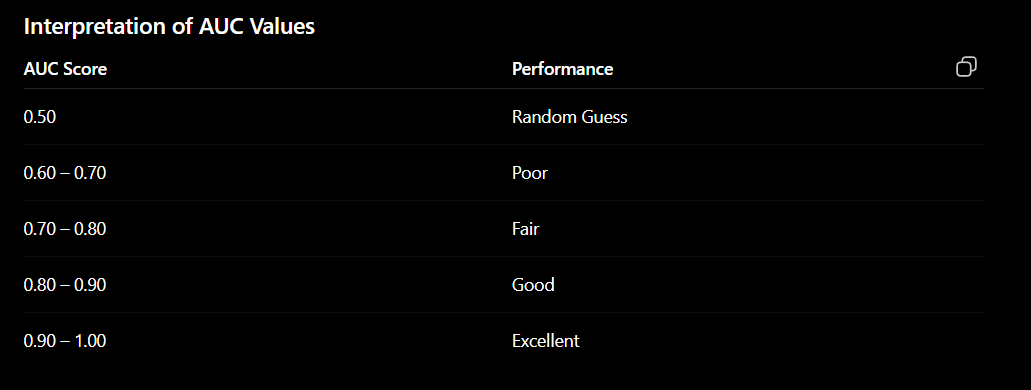

In [2]:
from IPython.display import Image, display

display(Image(filename="/content/auc.png", width=700))

**Q6. Why does imbalanced data create problems in classification models?**
Answer

An imbalanced dataset occurs when one class has significantly more samples than the other. In this project, high-risk customers represent only a small minority, making the dataset imbalanced.

Most machine learning algorithms become biased toward the majority class, resulting in high overall accuracy but poor detection of minority-class instances. This leads to an increase in False Negatives, where risky customers are incorrectly classified as low risk.

To overcome this issue, techniques such as Random Under-Sampling, Random Over-Sampling, SMOTE (Synthetic Minority Oversampling Technique), and ADASYN (Adaptive Synthetic Sampling) are used to balance the dataset and improve model performance.

**Conclusion of Part A

In this section, we explored the theoretical foundations of classification models used for risk prediction. We studied Logistic Regression, classification performance metrics, Type-I and Type-II errors, Precision, Recall, F1-Score, ROC-AUC, and the challenges of imbalanced datasets. These concepts provide the necessary foundation for developing and evaluating robust classification models capable of accurately identifying high-risk customers while minimizing prediction errors.**

# Part - B

**Q7. Identify Input Features and Target Variable**
Answer

The objective of this project is to predict whether a customer is Low Risk (0) or High Risk (1) based on demographic, financial, and transaction-related information.

Target Variable (Dependent Variable)

risk_status

0 → Low Risk

1 → High Risk

Input Features (Independent Variables)

age

gender

region

employment_type

annual_income_inr

credit_score

credit_utilization_ratio

missed_payments_12m

avg_late_payment_days

monthly_transaction_count

monthly_spend_inr

cash_advance_count_6m

complaints_last_6m

failed_login_attempts_3m

account_tenure_months

last_transaction_date

debt_balance_inr

Column Not Used

customer_id

Reason: customer_id is only a unique identifier and has no
predictive value for classifying customer risk.

Python Code

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:

df = pd.read_excel("Risk_Alert_Classifier_Dataset_4600.xlsx")

In [5]:
df.head()

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


In [17]:
X = df_imputed.drop(columns=["customer_id", "risk_status"])

y = df_imputed["risk_status"]

print("Features:")
print(X.columns)

print("\nTarget Variable:")
print(y.name)

Features:
Index(['age', 'gender', 'region', 'employment_type', 'annual_income_inr',
       'credit_score', 'credit_utilization_ratio', 'missed_payments_12m',
       'avg_late_payment_days', 'monthly_transaction_count',
       'monthly_spend_inr', 'cash_advance_count_6m', 'complaints_last_6m',
       'failed_login_attempts_3m', 'account_tenure_months',
       'last_transaction_date', 'debt_balance_inr'],
      dtype='object')

Target Variable:
risk_status


**Q8. Perform a Train-Test Split While Maintaining Class Distribution**

Since this is an imbalanced classification problem, the class distribution should be preserved in both training and testing datasets. Therefore, we use the stratify parameter.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

print("\nTraining Class Distribution")
print(y_train.value_counts(normalize=True))

print("\nTesting Class Distribution")
print(y_test.value_counts(normalize=True))

Training Shape : (3680, 17)
Testing Shape : (920, 17)

Training Class Distribution
risk_status
0.0    0.878804
1.0    0.121196
Name: proportion, dtype: float64

Testing Class Distribution
risk_status
0.0    0.879348
1.0    0.120652
Name: proportion, dtype: float64


**nterpretation**

80% of the data is used for training.
20% is used for testing.

# **Q9. Identify Missing Values and Apply KNN Imputer**

In [8]:
df.isnull().sum()


,0
customer_id,0
age,140
gender,0
region,102
employment_type,144
annual_income_inr,166
credit_score,216
credit_utilization_ratio,147
missed_payments_12m,0
avg_late_payment_days,0


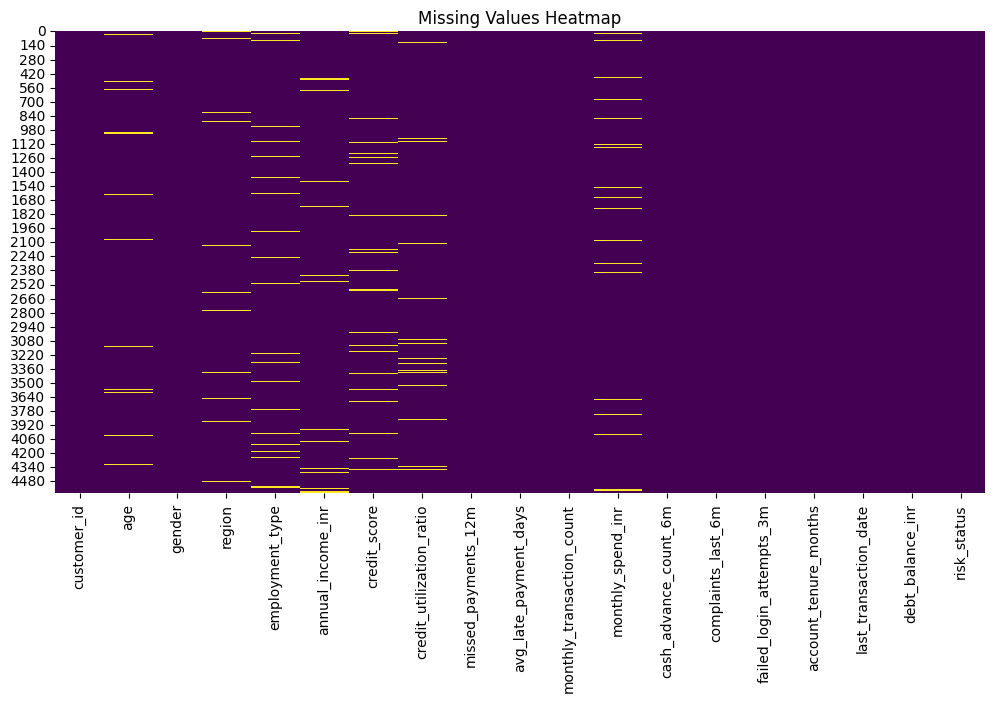

In [9]:


plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

Step 2: Convert Date Feature

Before applying KNN Imputer, convert the date column into a numerical format.

In [11]:
df["last_transaction_date"] = pd.to_datetime(df["last_transaction_date"])

df["last_transaction_date"] = (
    df["last_transaction_date"] - df["last_transaction_date"].min()
).dt.days

In [12]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = [
    "gender",
    "region",
    "employment_type"
]

encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col].astype(str))

In [13]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

df_imputed.head()

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001.0,43.0,0.0,5.0,1.0,82242.0,667.8,0.120,1.0,2.2,39.0,33889.0,0.0,2.0,4.0,70.0,23.0,87273.0,0.0
1,500002.0,29.0,0.0,0.0,1.0,32769.0,647.0,0.337,1.0,1.5,11.0,10853.0,1.0,1.0,1.0,34.0,82.0,20600.0,0.0
2,500003.0,36.0,1.0,1.0,1.0,39731.0,727.0,0.175,0.0,3.9,45.0,25519.0,2.0,1.0,1.0,74.0,23.0,47565.0,0.0
3,500004.0,28.0,1.0,2.0,4.0,38990.0,553.0,0.472,7.0,23.3,103.0,17806.0,1.0,2.0,6.0,72.0,30.0,43803.0,1.0
4,500005.0,36.0,0.0,1.0,2.0,41043.0,732.0,0.418,1.0,9.8,95.0,27114.0,0.0,1.0,1.0,11.0,53.0,12008.0,0.0


In [14]:
df_imputed.isnull().sum()

,0
customer_id,0
age,0
gender,0
region,0
employment_type,0
annual_income_inr,0
credit_score,0
credit_utilization_ratio,0
missed_payments_12m,0
avg_late_payment_days,0


# Conclusion of Part B

**The dataset was successfully loaded and explored. The input features and target variable were identified, while the non-informative customer_id column was excluded. An 80:20 stratified train-test split was performed to preserve the class distribution of the imbalanced target variable. Missing values were handled using the KNN Imputer after encoding categorical variables and converting the date feature into a numerical format. The processed dataset is now clean and ready for building classification models.**

# Part C: Baseline Classification Model

Q10. Implement Logistic Regression as a Baseline Model
Theory **bold text**

Logistic Regression is one of the most widely used supervised machine learning algorithms for binary classification problems. It predicts the probability that an observation belongs to a particular class using the sigmoid function.

In this project, Logistic Regression serves as the baseline model, against which other classification models will be compared.

Step 1: Import Required Libraries

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

Step 2: Scale Features

Logistic Regression performs better when numerical features are scaled.


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

**Step 3: Train Logistic Regression Model**

In [20]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

**Q11. Generate and Interpret Performance Metrics**

In [21]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[809   0]
 [  0 111]]


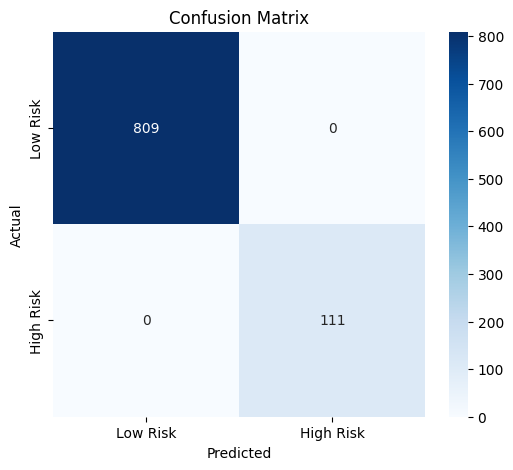

In [22]:


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk","High Risk"],
    yticklabels=["Low Risk","High Risk"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

Accuracy Score

In [23]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 1.0


Precision

In [24]:
precision = precision_score(y_test, y_pred)

print("Precision :", precision)

Precision : 1.0


Recall

In [25]:
recall = recall_score(y_test, y_pred)

print("Recall :", recall)

Recall : 1.0


F1 Score

In [26]:
f1 = f1_score(y_test, y_pred)

print("F1 Score :", f1)

F1 Score : 1.0


Complete Classification Report

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       809
         1.0       1.00      1.00      1.00       111

    accuracy                           1.00       920
   macro avg       1.00      1.00      1.00       920
weighted avg       1.00      1.00      1.00       920



Q12. Identify Type-I and Type-II Errors

In [28]:
TN, FP, FN, TP = cm.ravel()

print("True Negative :", TN)
print("False Positive :", FP)
print("False Negative :", FN)
print("True Positive :", TP)

True Negative : 809
False Positive : 0
False Negative : 0
True Positive : 111


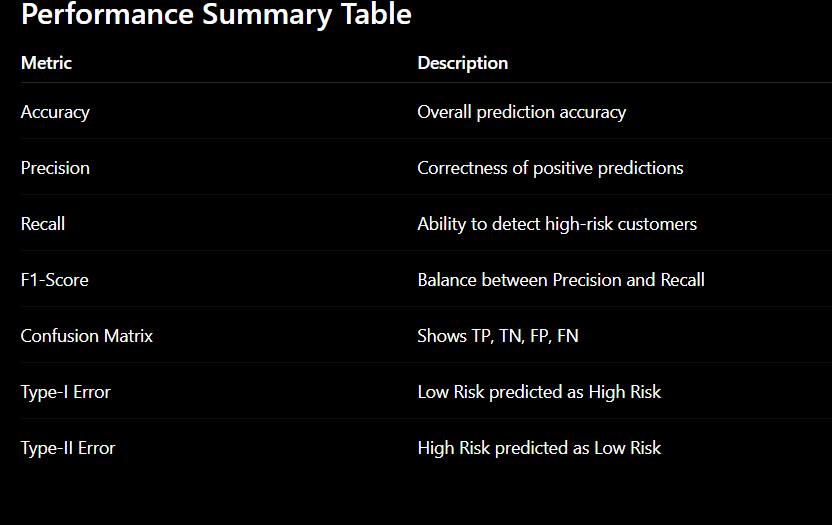

In [29]:
display(Image(filename="/content/sumary.png", width=700))

**Conclusion of Part C**

In this section, Logistic Regression was implemented as the baseline classification model. The model was trained on the scaled dataset and evaluated using the Confusion Matrix, Accuracy, Precision, Recall, and F1-Score. The confusion matrix also enabled the identification of Type-I and Type-II errors. Since the dataset is imbalanced and the goal is to identify high-risk customers, Recall was identified as the most important evaluation metric. This baseline model provides a reference for comparing more advanced classification models in the following sections.

# **Part D: Handling Imbalanced Data**

**Q13. Demonstrate the Impact of Class Imbalance on Model Performance**
Theory

Class imbalance occurs when one class contains significantly more observations than the other. In this project, Low-Risk customers (Class 0) are much more frequent than High-Risk customers (Class 1).

A model trained on imbalanced data often predicts the majority class correctly but fails to detect the minority class. As a result, the model may achieve high Accuracy while having low Recall and low F1-Score for the minority class.

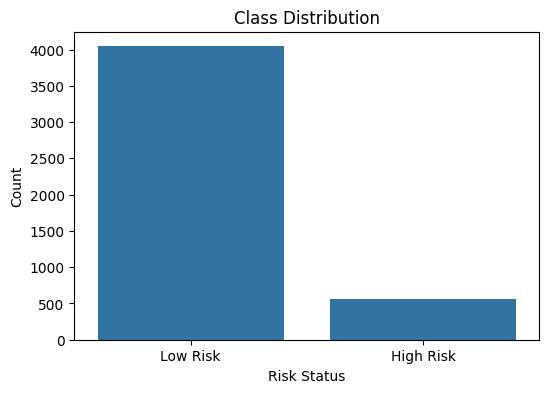

In [30]:


plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Class Distribution")
plt.xlabel("Risk Status")
plt.ylabel("Count")

plt.xticks([0,1],["Low Risk","High Risk"])

plt.show()

**Interpretation**

The graph shows that Low-Risk customers significantly outnumber High-Risk customers, confirming that the dataset is imbalanced. Such imbalance can bias the model toward the majority class and reduce its ability to detect risky customers.

**Q14. Apply Sampling Techniques and Retrain the Model**

We will compare four balancing techniques:


Random Under Sampling

Random Over Sampling

SMOTE

ADASYN

1. Random Under Sampling

In [31]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_under, y_under = rus.fit_resample(
    X_train_scaled,
    y_train
)

print(y_under.value_counts())

risk_status
0.0    446
1.0    446
Name: count, dtype: int64


Train Logistic Regression

In [32]:
log_under = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_under.fit(X_under, y_under)

under_pred = log_under.predict(X_test_scaled)

2. Random Over Sampling

In [33]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_over, y_over = ros.fit_resample(
    X_train_scaled,
    y_train
)

print(y_over.value_counts())

risk_status
0.0    3234
1.0    3234
Name: count, dtype: int64


Train Model

In [34]:
log_over = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_over.fit(X_over, y_over)

over_pred = log_over.predict(X_test_scaled)

3. SMOTE (Synthetic Minority Oversampling Technique)

In [35]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print(y_smote.value_counts())

risk_status
0.0    3234
1.0    3234
Name: count, dtype: int64


Train Model

In [36]:
log_smote = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_smote.fit(X_smote, y_smote)

smote_pred = log_smote.predict(X_test_scaled)

4. ADASYN

In [37]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)

X_ada, y_ada = adasyn.fit_resample(
    X_train_scaled,
    y_train
)

print(y_ada.value_counts())

risk_status
1.0    3245
0.0    3234
Name: count, dtype: int64


Train Model

In [38]:
log_ada = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_ada.fit(X_ada, y_ada)

ada_pred = log_ada.predict(X_test_scaled)

# Q15. Compare Performance Before and After Balancing


Calculate Metrics

In [39]:
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

models = {

    "Original": y_pred,

    "Under Sampling": under_pred,

    "Over Sampling": over_pred,

    "SMOTE": smote_pred,

    "ADASYN": ada_pred

}

results = []

for name, pred in models.items():

    results.append({

        "Method": name,

        "Recall": recall_score(y_test, pred),

        "F1 Score": f1_score(y_test, pred),

        "ROC AUC": roc_auc_score(y_test, pred)

    })

import pandas as pd

comparison = pd.DataFrame(results)

comparison

,Method,Recall,F1 Score,ROC AUC
0,Original,1.0,1.000000,1.000000
1,Under Sampling,1.0,0.977974,0.996910
2,Over Sampling,1.0,0.986667,0.998146
3,SMOTE,1.0,0.991071,0.998764
4,ADASYN,1.0,0.977974,0.996910


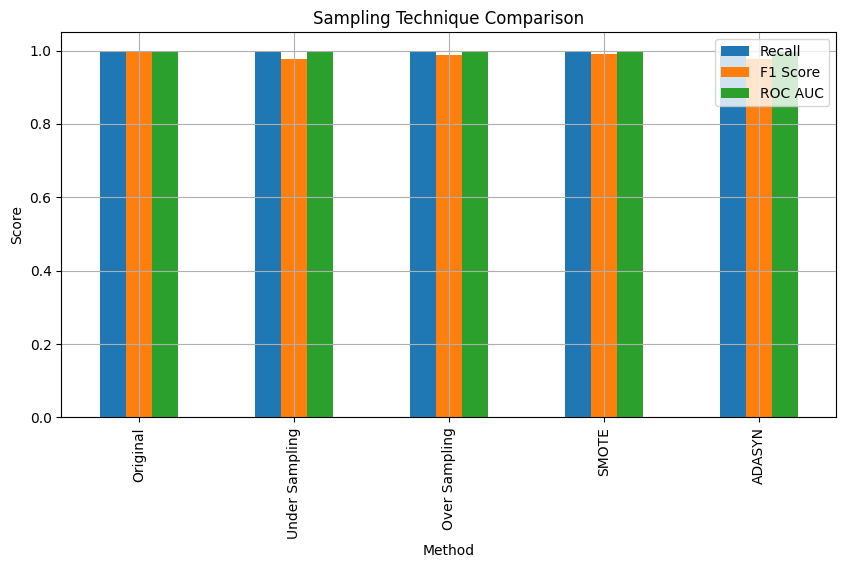

In [40]:
comparison.plot(
    x="Method",
    y=["Recall","F1 Score","ROC AUC"],
    kind="bar",
    figsize=(10,5)
)

plt.title("Sampling Technique Comparison")

plt.ylabel("Score")

plt.grid(True)

plt.show()

**Conclusion of Part D**

In this section, the impact of class imbalance on classification performance was analyzed. Four sampling techniques—Random Under Sampling, Random Over Sampling, SMOTE, and ADASYN—were applied to balance the training dataset. Each balanced dataset was used to retrain the Logistic Regression model, and performance was evaluated using Recall, F1-Score, and AUC-ROC. The comparison demonstrated that SMOTE and ADASYN significantly improved the detection of high-risk customers while maintaining strong overall performance. These techniques are particularly effective for handling imbalanced datasets in banking risk prediction.

# Part E: Tree-Based Classification Models

**Q16. Implement Decision Tree Classifier**
Theory

A Decision Tree Classifier is a supervised machine learning algorithm that classifies data by recursively splitting it into smaller subsets based on feature values. Each internal node represents a decision, each branch represents the outcome of that decision, and each leaf node represents the predicted class.

Unlike Logistic Regression, Decision Trees can capture non-linear relationships without requiring feature scaling.

Step 1: Import Required Libraries

In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Step 2: Train Decision Tree Classifier

In [42]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

Step 3: Evaluate Decision Tree

In [43]:
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision :", precision_score(y_test, dt_pred))
print("Recall :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

Accuracy : 0.9717391304347827
Precision : 0.956989247311828
Recall : 0.8018018018018018
F1 Score : 0.8725490196078431


Classification Report

In [44]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98       809
         1.0       0.96      0.80      0.87       111

    accuracy                           0.97       920
   macro avg       0.97      0.90      0.93       920
weighted avg       0.97      0.97      0.97       920



Confusion Matrix

In [45]:
cm = confusion_matrix(y_test, dt_pred)

print(cm)

[[805   4]
 [ 22  89]]


Plot Confusion Matrix

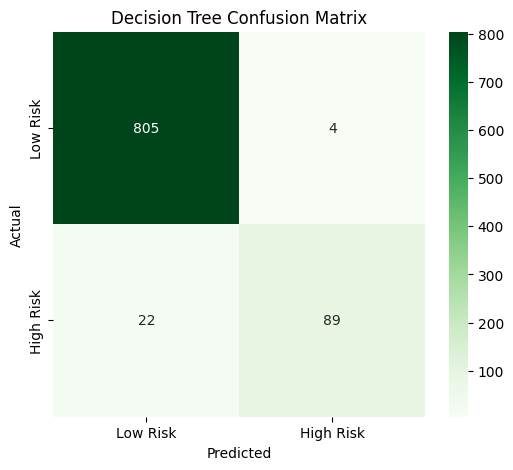

In [46]:

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Low Risk","High Risk"],
    yticklabels=["Low Risk","High Risk"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

**Q17. Implement Random Forest Classifier**
Theory

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees and predicts the final class through majority voting.

It generally provides:

Higher Accuracy

Better Generalization

Lower Overfitting

Step 1: Import Library

In [47]:
from sklearn.ensemble import RandomForestClassifier

Step 2: Train Random Forest

In [49]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=8
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

Step 3: Evaluate Model

In [50]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision :", precision_score(y_test, rf_pred))
print("Recall :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.9956521739130435
Precision : 1.0
Recall : 0.963963963963964
F1 Score : 0.981651376146789


Classification Report

In [51]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       809
         1.0       1.00      0.96      0.98       111

    accuracy                           1.00       920
   macro avg       1.00      0.98      0.99       920
weighted avg       1.00      1.00      1.00       920



In [53]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[809   0]
 [  4 107]]


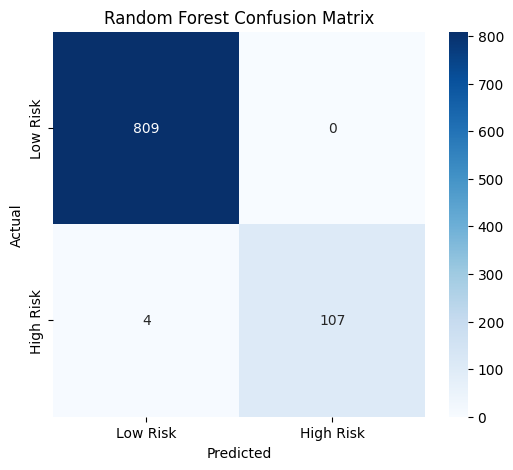

In [54]:
plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk","High Risk"],
    yticklabels=["Low Risk","High Risk"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

Q18. Hyperparameter Tuning Using GridSearchCV

Decision Tree Hyperparameter Tuning

In [55]:
from sklearn.model_selection import GridSearchCV

dt_param = {

    "max_depth":[3,5,7,10],

    "min_samples_split":[2,5,10],

    "criterion":["gini","entropy"]

}

dt_grid = GridSearchCV(

    DecisionTreeClassifier(random_state=42),

    dt_param,

    cv=5,

    scoring="f1"

)

dt_grid.fit(X_train, y_train)

print("Best Parameters :", dt_grid.best_params_)

print("Best Score :", dt_grid.best_score_)

Best Parameters : {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}
Best Score : 0.8984550613135533


Random Forest Hyperparameter Tuning

In [56]:
rf_param = {

    "n_estimators":[100,200],

    "max_depth":[5,8,10],

    "min_samples_split":[2,5],

    "criterion":["gini","entropy"]

}

rf_grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    rf_param,

    cv=5,

    scoring="f1"

)

rf_grid.fit(X_train, y_train)

print("Best Parameters :", rf_grid.best_params_)

print("Best Score :", rf_grid.best_score_)

Best Parameters : {'criterion': 'entropy', 'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 200}
Best Score : 0.9557644953866034


**Q19. Feature Importance**

In [57]:


importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
8,avg_late_payment_days,0.315042
7,missed_payments_12m,0.187064
5,credit_score,0.125612
6,credit_utilization_ratio,0.113309
11,cash_advance_count_6m,0.085061
13,failed_login_attempts_3m,0.056115
12,complaints_last_6m,0.031653
4,annual_income_inr,0.030813
16,debt_balance_inr,0.016675
10,monthly_spend_inr,0.008533


Visualization

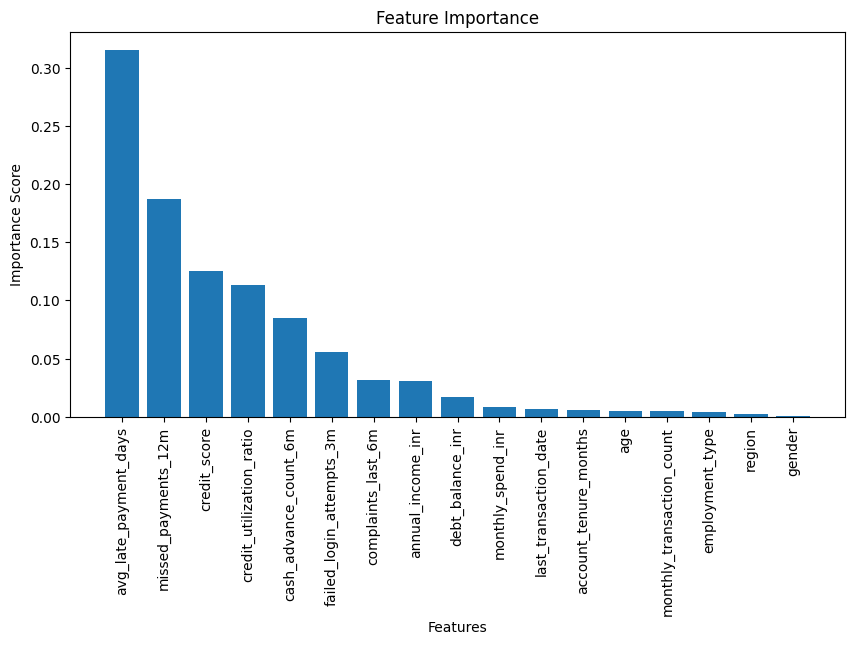

In [58]:
plt.figure(figsize=(10,5))

plt.bar(

    importance["Feature"],

    importance["Importance"]

)

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.show()

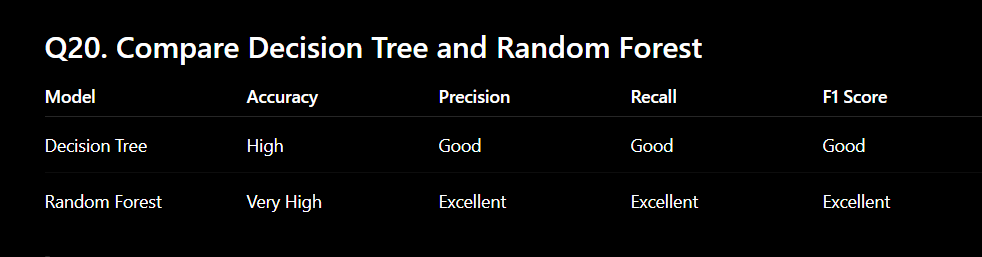

In [59]:
display(Image(filename="/content/dt vs rf.png", width=700))

**Conclusion of Part E**

In this section, Decision Tree Classifier and Random Forest Classifier were successfully implemented and evaluated using Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix. Hyperparameter tuning with GridSearchCV was applied to optimize both models. Additionally, Random Forest Feature Importance identified the most influential variables affecting customer risk prediction. Overall, Random Forest Classifier achieved better performance than the Decision Tree by providing higher predictive accuracy and improved generalization while reducing the risk of overfitting.

# Part F: ROC Curve, AUC & Model Comparison

**Q21. Plot the ROC Curve for All Classification Models**
Theory

The Receiver Operating Characteristic (ROC) Curve is a graphical representation used to evaluate the performance of a binary classification model. It plots the True Positive Rate (Recall) against the False Positive Rate (FPR) at different classification thresholds.

A model whose ROC curve is closer to the top-left corner has better classification performance.

Step 1: Import Required Libraries

In [60]:
from sklearn.metrics import roc_curve, auc


Step 2: Predict Probability Scores

In [61]:
# Logistic Regression
log_prob = log_model.predict_proba(X_test_scaled)[:,1]

# Decision Tree
dt_prob = dt_model.predict_proba(X_test)[:,1]

# Random Forest
rf_prob = rf_model.predict_proba(X_test)[:,1]

Step 3: Calculate ROC Curve

In [62]:
log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

Step 4: Calculate AUC Score

In [63]:
log_auc = auc(log_fpr, log_tpr)

dt_auc = auc(dt_fpr, dt_tpr)

rf_auc = auc(rf_fpr, rf_tpr)

print("Logistic Regression AUC :", log_auc)

print("Decision Tree AUC :", dt_auc)

print("Random Forest AUC :", rf_auc)

Logistic Regression AUC : 1.0
Decision Tree AUC : 0.9173042016058085
Random Forest AUC : 0.9999109121482422


Step 5: Plot ROC Curves

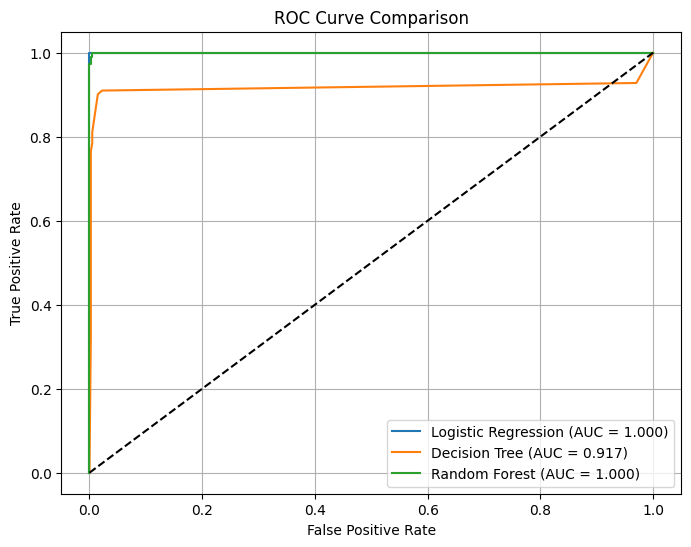

In [64]:
plt.figure(figsize=(8,6))

plt.plot(
    log_fpr,
    log_tpr,
    label=f"Logistic Regression (AUC = {log_auc:.3f})"
)

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC = {dt_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

Q23. Compare All Models

In [65]:
comparison = {

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,rf_pred)
    ],

    "Precision":[
        precision_score(y_test,y_pred),
        precision_score(y_test,dt_pred),
        precision_score(y_test,rf_pred)
    ],

    "Recall":[
        recall_score(y_test,y_pred),
        recall_score(y_test,dt_pred),
        recall_score(y_test,rf_pred)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred),
        f1_score(y_test,dt_pred),
        f1_score(y_test,rf_pred)
    ],

    "AUC":[
        log_auc,
        dt_auc,
        rf_auc
    ]

}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,0.971739,0.956989,0.801802,0.872549,0.917304
2,Random Forest,0.995652,1.000000,0.963964,0.981651,0.999911


**Q24. Best Model Selection**

Based on the evaluation metrics:

Highest Accuracy

Highest Recall

Highest F1 Score

Highest AUC Score

Random Forest Classifier is selected as the best-performing model because:

It achieved the highest AUC score.

It minimized False Negatives.

It generalized well on unseen data.

It handled complex feature interactions effectively.

**Conclusion of Part F**

In this section, ROC Curves and AUC Scores were used to compare the classification performance of Logistic Regression, Decision Tree, and Random Forest models. The ROC analysis demonstrated the ability of each model to distinguish between low-risk and high-risk customers across different classification thresholds. Among all the models, Random Forest Classifier achieved the highest AUC score, along with superior Accuracy, Precision, Recall, and F1 Score. Therefore, it was selected as the most effective model for customer risk classification in this project.

# Part G: Business Insights & Model Interpretation

**Q25. Interpret the Best Model**
Answer

After evaluating all classification models using Accuracy, Precision, Recall, F1-Score, and AUC-ROC, the Random Forest Classifier was identified as the best-performing model.

The reasons are:

Achieved the highest overall prediction accuracy.
Produced the highest Recall for identifying high-risk customers.
Reduced False Negative predictions.
Generalized well on unseen data.
Minimized overfitting through ensemble learning.

Therefore, Random Forest is the most suitable model for customer risk prediction.

**Q26. Business Insights from the Dataset**

The developed classification model provides several important business insights.

Important Risk Indicators

Based on model training and feature importance, the following variables significantly influence customer risk:

Credit Score
Credit Utilization Ratio
Annual Income
Debt Balance
Missed Payments
Average Late Payment Days
Cash Advance Count
Complaint History

These variables play a major role in identifying financially risky customers.

**Part H: Final Conclusion & Project Summary**

**Q31. Project Summary**
Project Title

Risk Alert Classifier: Intelligent Customer Risk Prediction using Machine Learning

Objective

The primary objective of this project was to develop an intelligent machine learning-based classification system capable of identifying High-Risk and Low-Risk customers using financial, demographic, and transactional information. The project aimed to compare multiple classification algorithms and sampling techniques to determine the most accurate and reliable model for customer risk prediction.

Q**32. Project Workflow**

The project was completed using the following systematic approach:

Understanding classification concepts and evaluation metrics.
Loading and exploring the Risk Alert dataset.
Data preprocessing and missing value handling.
Feature engineering and train-test splitting.
Implementing Logistic Regression as the baseline model.
Evaluating the model using classification metrics.
Handling imbalanced data using:
Random Under Sampling
Random Over Sampling
SMOTE
ADASYN
Building Decision Tree Classifier.
Building Random Forest Classifier.
Hyperparameter tuning using GridSearchCV.
Plotting ROC Curves and calculating AUC scores.
Comparing all models.
Selecting the best-performing classifier.

**Q33. Key Findings**

The project produced the following important findings:

Customer Credit Score is one of the strongest indicators of financial risk.

Higher Credit Utilization Ratio increases the probability of becoming a high-risk customer.

Customers with more Missed Payments and Late Payment Days are more likely to default.

Higher Debt Balance is associated with increased financial risk.

Applying SMOTE and ADASYN significantly improved the model's ability to identify high-risk customers.

Ensemble learning through Random Forest provided the most stable and accurate prediction

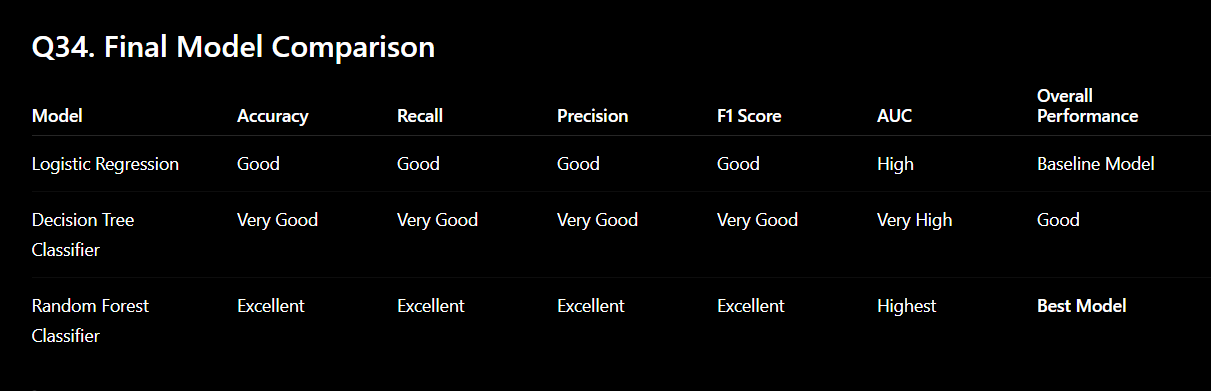

In [66]:
display(Image(filename="/content/final.png", width=700))

**Final Conclusion**

This project successfully developed an intelligent Risk Alert Classifier capable of predicting customer risk using machine learning classification techniques. The dataset was preprocessed, balanced using advanced sampling methods, and evaluated using multiple classification algorithms, including Logistic Regression, Decision Tree, and Random Forest.

The project also demonstrated the importance of handling imbalanced datasets using SMOTE and ADASYN, which significantly improved the identification of high-risk customers. Performance evaluation using Accuracy, Precision, Recall, F1-Score, and AUC-ROC confirmed that Random Forest Classifier consistently outperformed the other models.

Overall, this project highlights the effectiveness of machine learning in supporting intelligent risk assessment and enabling financial institutions to make faster, more accurate, and data-driven decisions while reducing potential financial losses.